# Stock Ranking / Alpha Research Pipeline

## 0. Imports and configuration

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import Ridge

warnings.filterwarnings("ignore")

# -----------------------------
# Configuration
# -----------------------------
DATA_PATH = Path("data.csv")

FEATURES = [
    "sharpe",
    "sortino",
    "volatility",
    "maxDD",
    "beta",
    "alpha",
    "infoRatio",
]

DATE_COL = "date"
SYMBOL_COL = "symbol"
INDUSTRY_COL = "industry"
PRICE_COL = "close"

FORWARD_DAYS = 20

# Preferred target if it already exists in your dataset.
TARGET_COL = "forward_20d_excess_return"

# Optional benchmark price column.
# Example: if every stock/date row contains the corresponding market index close.
BENCHMARK_PRICE_COL = "benchmark_close"

RANDOM_STATE = 42

## 1. Load and audit the dataset

In [2]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

missing_features = [c for c in FEATURES if c not in df.columns]
if missing_features:
    raise ValueError(f"Missing required feature columns: {missing_features}")

if DATE_COL in df.columns:
    df[DATE_COL] = pd.to_datetime(df[DATE_COL], errors="coerce")

display(df.head())

Shape: (699, 20)

Columns:
['symbol', 'name', 'industry', 'ret1y', 'sharpe', 'sortino', 'volatility', 'maxDD', 'beta', 'alpha', 'infoRatio', 'sortinoStatus', 'observationCount', 'benchmark', 'riskFreeRate', 'generatedAt', 'requestedStart', 'requestedEnd', 'windowCode', 'cacheKey']


,symbol,name,industry,ret1y,sharpe,sortino,volatility,maxDD,beta,alpha,infoRatio,sortinoStatus,observationCount,benchmark,riskFreeRate,generatedAt,requestedStart,requestedEnd,windowCode,cacheKey
0,360.AX,LIFE360 INC,Information Technology,-0.495287,-0.601118,-0.911109,0.723456,-0.676948,1.862379,-0.286111,-0.459145,ok,249,^AXJO,0.0435,2026-08-19T00:20:53.734601+00:00,2025-08-19,2026-08-19,1Y,"[""top-picks-snapshot"",""1Y"",""^AXJO"",0.0435,1000..."
1,A,Agilent Technologies,Health Care,0.245784,0.894325,1.240016,0.328343,-0.297474,-0.218928,0.314143,0.934030,ok,243,^AXJO,0.0435,2026-08-19T00:20:53.734601+00:00,2025-08-19,2026-08-19,1Y,"[""top-picks-snapshot"",""1Y"",""^AXJO"",0.0435,1000..."
2,A2M.AX,A2 MILK CO LTD/THE,Consumer Staples,-0.131659,-0.309020,-0.395117,0.382170,-0.474480,0.829946,-0.176131,-0.470857,ok,249,^AXJO,0.0435,2026-08-19T00:20:53.734601+00:00,2025-08-19,2026-08-19,1Y,"[""top-picks-snapshot"",""1Y"",""^AXJO"",0.0435,1000..."
3,AAI.AX,ALCOA CORP,Materials,0.601465,1.350170,1.650363,0.495337,-0.474540,1.596566,0.713065,1.517950,ok,249,^AXJO,0.0435,2026-08-19T00:20:53.734601+00:00,2025-08-19,2026-08-19,1Y,"[""top-picks-snapshot"",""1Y"",""^AXJO"",0.0435,1000..."
4,AAPL,Apple Inc.,Information Technology,0.349650,1.206839,1.692063,0.250595,-0.137985,0.010347,0.323929,1.262826,ok,243,^AXJO,0.0435,2026-08-19T00:20:53.734601+00:00,2025-08-19,2026-08-19,1Y,"[""top-picks-snapshot"",""1Y"",""^AXJO"",0.0435,1000..."


In [3]:
# Basic data quality report
quality = pd.DataFrame({
    "dtype": df[FEATURES].dtypes.astype(str),
    "missing_n": df[FEATURES].isna().sum(),
    "missing_pct": df[FEATURES].isna().mean() * 100,
    "n_unique": df[FEATURES].nunique(),
    "mean": df[FEATURES].mean(),
    "std": df[FEATURES].std(),
    "min": df[FEATURES].min(),
    "max": df[FEATURES].max(),
})

display(quality.round(4))

if DATE_COL in df.columns:
    print("\nDate range:", df[DATE_COL].min(), "→", df[DATE_COL].max())
    print("Unique dates:", df[DATE_COL].nunique())

if SYMBOL_COL in df.columns:
    print("Unique stocks:", df[SYMBOL_COL].nunique())

,dtype,missing_n,missing_pct,n_unique,mean,std,min,max
sharpe,float64,3,0.4292,696,0.3519,0.9190,-4.8750,3.5822
sortino,float64,3,0.4292,696,0.5436,1.3977,-4.6853,6.4209
volatility,float64,3,0.4292,696,0.3529,0.1484,0.0119,1.1730
maxDD,float64,3,0.4292,696,-0.2928,0.1440,-0.9114,-0.0147
beta,float64,3,0.4292,696,0.3172,0.6146,-0.9327,3.0014
alpha,float64,3,0.4292,696,0.1560,0.4376,-1.9447,4.4250
infoRatio,float64,3,0.4292,696,0.4202,0.8793,-2.6509,3.6954


Unique stocks: 699


## 2. Metric correlation and redundancy

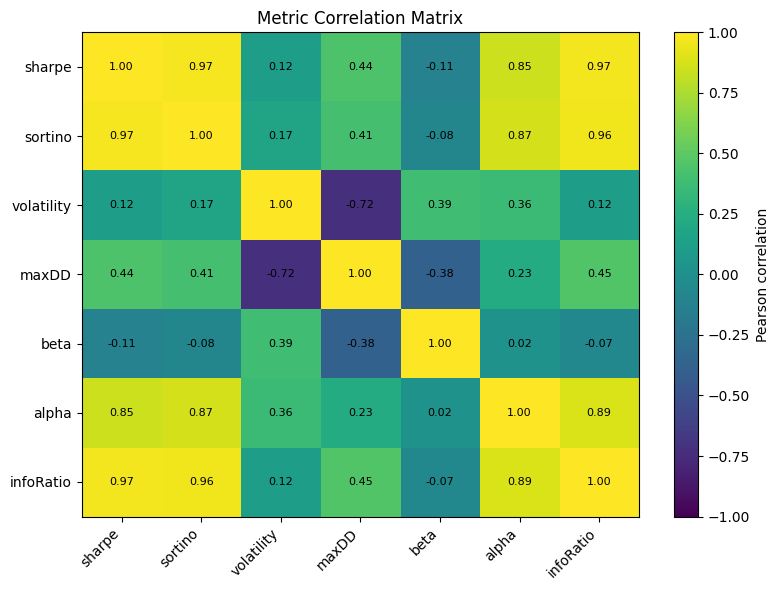

In [4]:
metric_df = df[FEATURES].dropna().copy()

corr = metric_df.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, aspect="auto")
fig.colorbar(im, ax=ax, label="Pearson correlation")

ax.set_xticks(range(len(FEATURES)))
ax.set_xticklabels(FEATURES, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES)
ax.set_title("Metric Correlation Matrix")

for i in range(len(FEATURES)):
    for j in range(len(FEATURES)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()

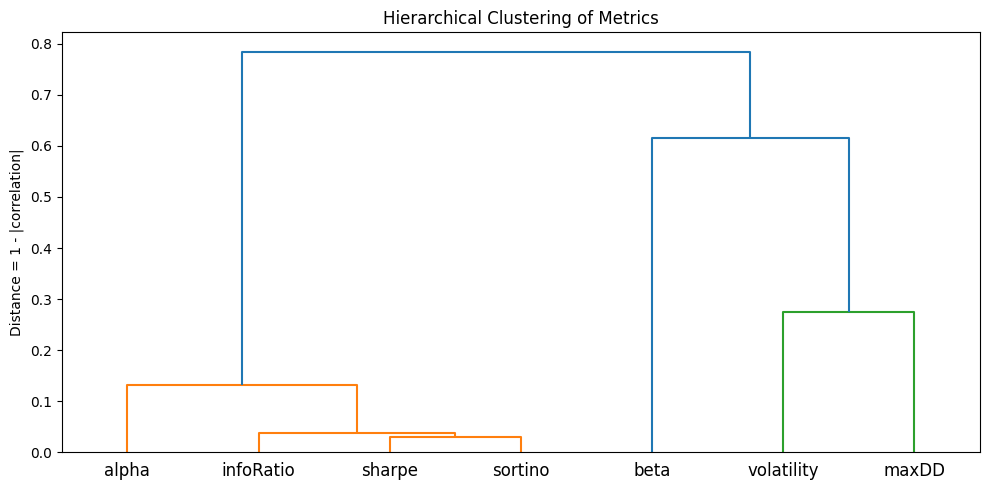

In [5]:
# Hierarchical clustering of METRICS, not stocks.
# Distance = 1 - |correlation|.
distance_matrix = 1 - corr.abs()

# Numerical cleanup
np.fill_diagonal(distance_matrix.values, 0)
condensed = squareform(distance_matrix.values, checks=False)

Z = linkage(condensed, method="average")

plt.figure(figsize=(10, 5))
dendrogram(Z, labels=FEATURES)
plt.title("Hierarchical Clustering of Metrics")
plt.ylabel("Distance = 1 - |correlation|")
plt.tight_layout()
plt.show()

## 3. PCA: dimensionality reduction

In [6]:
X_explore = df[FEATURES].dropna()

explore_scaler = StandardScaler()
X_scaled = explore_scaler.fit_transform(X_explore)

explore_pca = PCA()
X_pca = explore_pca.fit_transform(X_scaled)

explained = explore_pca.explained_variance_ratio_
cum_explained = explained.cumsum()

pca_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(explained))],
    "explained_variance": explained,
    "cumulative_variance": cum_explained,
})

display(pca_variance.round(4))

,component,explained_variance,cumulative_variance
0,PC1,0.5687,0.5687
1,PC2,0.2877,0.8564
2,PC3,0.1020,0.9584
3,PC4,0.0218,0.9803
4,PC5,0.0117,0.9919
5,PC6,0.0051,0.9971
6,PC7,0.0029,1.0000


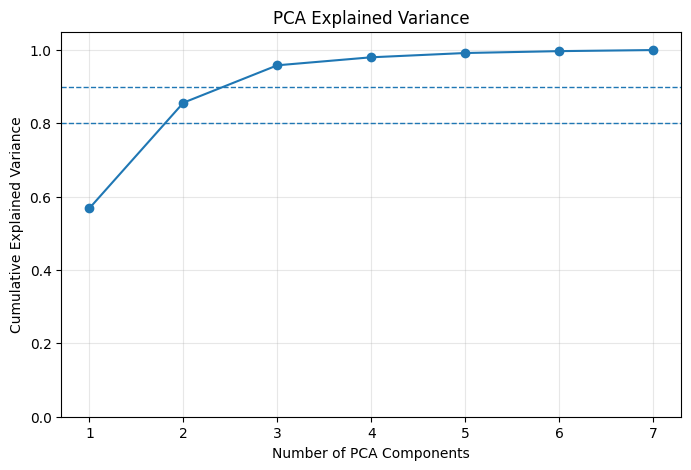

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cum_explained) + 1),
    cum_explained,
    marker="o"
)
plt.axhline(0.80, linestyle="--", linewidth=1)
plt.axhline(0.90, linestyle="--", linewidth=1)
plt.xlabel("Number of PCA Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.show()

In [8]:
loadings = pd.DataFrame(
    explore_pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(FEATURES))],
    index=FEATURES,
)

display(loadings.round(3))

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
sharpe,0.491,0.013,-0.002,-0.440,-0.042,-0.123,0.741
sortino,0.490,0.049,0.001,-0.328,0.166,0.681,-0.398
volatility,0.056,0.659,-0.328,0.131,0.642,-0.159,0.038
maxDD,0.246,-0.562,0.319,0.348,0.624,-0.076,0.077
beta,-0.064,0.459,0.885,-0.018,-0.006,0.023,0.030
alpha,0.455,0.192,-0.064,0.740,-0.381,0.193,0.145
infoRatio,0.494,0.026,0.054,-0.110,-0.156,-0.672,-0.514


In [9]:
# Select the smallest number of PCs that explain at least 90% variance.
N_PCS_EXPLORE = int(np.argmax(cum_explained >= 0.90) + 1)

print("PCA components needed for >=90% explained variance:", N_PCS_EXPLORE)

PCA components needed for >=90% explained variance: 3


## 4. Exploratory stock clustering

In [10]:
X_cluster = X_pca[:, :N_PCS_EXPLORE]

max_k = min(10, len(X_cluster) - 1)

if max_k < 2:
    print("Not enough observations for KMeans clustering.")
else:
    cluster_results = []

    for k in range(2, max_k + 1):
        km = KMeans(
            n_clusters=k,
            random_state=RANDOM_STATE,
            n_init=10,
        )
        labels_k = km.fit_predict(X_cluster)

        cluster_results.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_cluster, labels_k),
        })

    cluster_results = pd.DataFrame(cluster_results)
    display(cluster_results.round(4))

,k,inertia,silhouette
0,2,2980.6893,0.3347
1,3,2222.5067,0.3479
2,4,1790.6163,0.3067
3,5,1495.2860,0.3154
4,6,1326.2777,0.3226
5,7,1174.6915,0.2892
6,8,1053.7902,0.3073
7,9,962.8614,0.2863
8,10,888.1175,0.2944


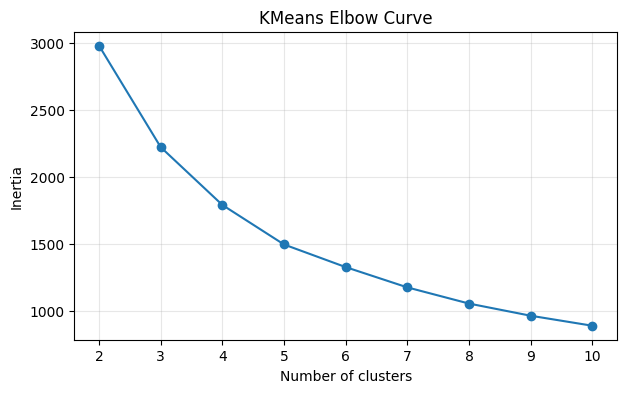

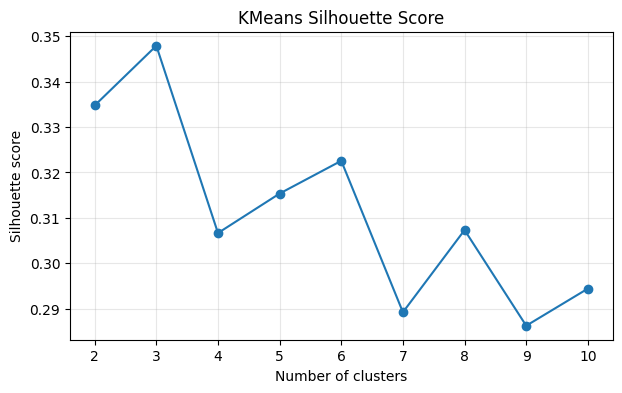

In [11]:
if max_k >= 2:
    plt.figure(figsize=(7, 4))
    plt.plot(cluster_results["k"], cluster_results["inertia"], marker="o")
    plt.xlabel("Number of clusters")
    plt.ylabel("Inertia")
    plt.title("KMeans Elbow Curve")
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(cluster_results["k"], cluster_results["silhouette"], marker="o")
    plt.xlabel("Number of clusters")
    plt.ylabel("Silhouette score")
    plt.title("KMeans Silhouette Score")
    plt.grid(alpha=0.3)
    plt.show()

In [12]:
if max_k >= 2:
    best_k = int(
        cluster_results.loc[
            cluster_results["silhouette"].idxmax(),
            "k"
        ]
    )

    print("Best k by silhouette:", best_k)

    final_kmeans = KMeans(
        n_clusters=best_k,
        random_state=RANDOM_STATE,
        n_init=10,
    )

    best_labels = final_kmeans.fit_predict(X_cluster)

    cluster_summary = df.loc[X_explore.index].copy()
    cluster_summary["cluster"] = best_labels

    display(
        cluster_summary
        .groupby("cluster")[FEATURES]
        .mean()
        .round(3)
    )

Best k by silhouette: 3


,sharpe,sortino,volatility,maxDD,beta,alpha,infoRatio
cluster,,,,,,,
0,-0.587,-0.810,0.387,-0.410,0.445,-0.194,-0.481
1,1.483,2.416,0.548,-0.347,0.816,0.887,1.619
2,0.675,0.946,0.279,-0.201,0.102,0.195,0.700


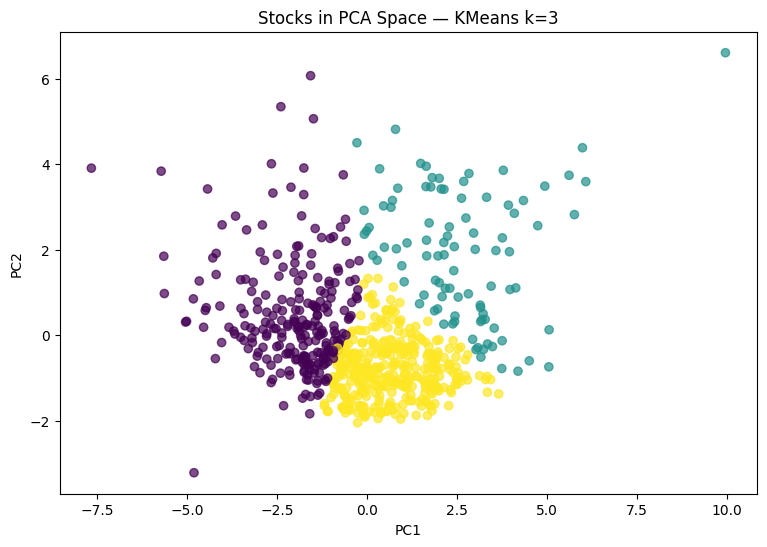

In [13]:
if max_k >= 2 and X_pca.shape[1] >= 2:
    plt.figure(figsize=(9, 6))
    plt.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=best_labels,
        alpha=0.7,
    )
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"Stocks in PCA Space — KMeans k={best_k}")
    plt.show()

## Linear regression
Use `ret1y`-prediction as an example.

In [15]:
# -------------------------
# Handle missing values
# -------------------------

features = [
    "sharpe",
    "sortino",
    "volatility",
    "maxDD",
    "beta",
    "alpha",
    "infoRatio"
]

# Keep only the columns needed for Linear Regression
data = df[features + ["ret1y"]].copy()

# Show how many missing values exist in each column
print("Missing values before cleaning:")
print(data.isna().sum())

# Remove rows where any feature or ret1y contains NaN
data = data.dropna()

# Replace the original modelling data with the cleaned data
X = data[features]
y = data["ret1y"]

print("\nNumber of rows after removing NaN:", len(data))

Missing values before cleaning:
sharpe        3
sortino       3
volatility    3
maxDD         3
beta          3
alpha         3
infoRatio     3
ret1y         3
dtype: int64

Number of rows after removing NaN: 696


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = data[features]
y = data["ret1y"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

model = LinearRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("R²:", r2_score(y_test, y_pred))

print(
    "RMSE:",
    mean_squared_error(y_test, y_pred) ** 0.5
)

R²: -1.623931948802356
RMSE: 0.8635017143253988


## Classification

In [19]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# -------------------------
# 1. Select features
# -------------------------
features = [
    "sharpe",
    "sortino",
    "volatility",
    "maxDD",
    "beta",
    "alpha",
    "infoRatio"
]

# Remove rows with missing values
data = df[features + ["ret1y"]].dropna().copy()

# -------------------------
# 2. Create classification target
# -------------------------
# 1 = positive one-year return
# 0 = zero or negative one-year return
data["target"] = (data["ret1y"] > 0).astype(int)

X = data[features]
y = data["target"]

print("Class distribution:")
print(y.value_counts())

# -------------------------
# 3. Train-test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# -------------------------
# 4. Standardisation
# -------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------
# 5. Train classifier
# -------------------------
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

# -------------------------
# 6. Prediction
# -------------------------
y_pred = model.predict(X_test_scaled)

# Probability of class 1
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# -------------------------
# 7. Evaluation
# -------------------------
print("\nAccuracy:")
print(accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Class distribution:
target
1    430
0    266
Name: count, dtype: int64

Accuracy:
0.9785714285714285

Confusion Matrix:
[[52  2]
 [ 1 85]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        54
           1       0.98      0.99      0.98        86

    accuracy                           0.98       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



In [20]:
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    "abs_coefficient",
    ascending=False
)

display(coef_df)

,feature,coefficient,abs_coefficient
1,sortino,5.023211,5.023211
0,sharpe,1.527569,1.527569
6,infoRatio,1.024473,1.024473
3,maxDD,0.951946,0.951946
5,alpha,0.948488,0.948488
2,volatility,-0.521384,0.521384
4,beta,0.224014,0.224014


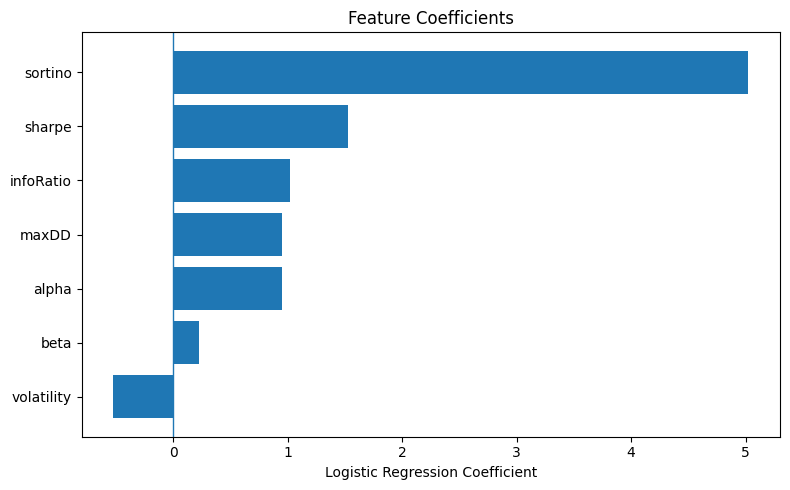

In [21]:
import matplotlib.pyplot as plt

coef_df_sorted = coef_df.sort_values("coefficient")

plt.figure(figsize=(8, 5))
plt.barh(
    coef_df_sorted["feature"],
    coef_df_sorted["coefficient"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Logistic Regression Coefficient")
plt.title("Feature Coefficients")
plt.tight_layout()
plt.show()

In [22]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

pca_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

pca_model.fit(X_train_pca, y_train)

y_pred_pca = pca_model.predict(X_test_pca)

print("PCA Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_pca))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_pca))

PCA Logistic Regression Accuracy:
0.9785714285714285

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        54
           1       0.98      0.99      0.98        86

    accuracy                           0.98       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.98      0.98      0.98       140



In [23]:
print(
    "Original features accuracy:",
    accuracy_score(y_test, y_pred)
)

print(
    "PCA features accuracy:",
    accuracy_score(y_test, y_pred_pca)
)

Original features accuracy: 0.9785714285714285
PCA features accuracy: 0.9785714285714285
